In [77]:
import json
import pandas as pd
from pathlib import Path
from typing import List, Tuple, Dict, Optional

import matplotlib.pyplot as plt

In [78]:
# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams["font.family"] = "Times New Roman"

colors = {
    "SlateGrey":     "#2E2E2E",
    "LightGrey":     "#7D7D7D",
    "PastelRed":     "#8F0D0D",
    "DarkPastelRed": "#450808",
}

pylint_messages = [
    "E0601",  # Using variable before assignment
    # "E0602",  # Undefined variable
    # "E0611",  # No name in module
    # "W0611",  # Unused import
    # "E0102",  # Class already defined
    # "W0237",  # Parameter renamed in overriding method
    # "W0612",  # Unused variable
    # "W0613",  # Unused argument
    # "R0903",  # Too few public methods
    # "W0246",  # Useless parent delegation
    # "W0404",  # Reimport
    # "C0103",  # Variable name doesn't conform to snake_case
    # "W0127",  # Assigning the same variable to itself
    # "W0622",  # Redefining built-in
    # "W0511",  # TODO comment
    # "W0101",  # Unreachable code
]

Groups = ['E', 'W', 'R', 'C']

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR   = Path().resolve()
CSV_PATH   = BASE_DIR / "../data/wger-results/pylint_analysis" / "pylint_results.csv"
JSON_DIR   = BASE_DIR / "../data/wger-results/json_output"
OUTPUT_DIR = BASE_DIR / "../visualizations"

In [79]:

# ── Caches ─────────────────────────────────────────────────────────────────────
# Both caches are module-level dicts so repeated calls within a notebook session
# never touch disk a second time.
 
_df_cache:   Optional[pd.DataFrame] = None   # deduplicated commit index
_json_cache: Dict[str, Optional[list]] = {}  # commit hash → parsed JSON (or None)
 
 
def clear_cache() -> None:
    """Invalidate both caches (call if the underlying files change mid-session)."""
    global _df_cache
    _df_cache = None
    _json_cache.clear()
    print("Cache cleared.")
 
 
# ── Data loading ───────────────────────────────────────────────────────────────
 
def _load_commit_index_raw() -> pd.DataFrame:
    """Read and parse the CSV; return oldest-first. Internal – use load_data()."""
    # Detect whether the CSV has a header row by checking if the first field looks
    # like a 40-char hex commit hash (data row) or a plain label (header row).
    with open(CSV_PATH, encoding="utf-8") as fh:
        first_field = fh.readline().split(",")[0].strip()
    has_header = not all(c in "0123456789abcdefABCDEF" for c in first_field)
 
    df = pd.read_csv(CSV_PATH, header=0 if has_header else None, dtype=str)
 
    # Normalise to the expected column names regardless of source format.
    if not has_header:
        df = df.rename(columns={0: "commit", 1: "date"})
    else:
        if "commit" not in df.columns:
            df = df.rename(columns={df.columns[0]: "commit"})
        if "date" not in df.columns:
            df = df.rename(columns={df.columns[1]: "date"})
 
    # Drop blank separator rows (empty commit hash or empty date).
    df = df.dropna(subset=["commit", "date"])
    df = df[df["commit"].str.strip().astype(bool)]
    df = df[df["date"].str.strip().astype(bool)]
 
    # Parse mixed date formats: e.g. "5/11/2022 9:50" and "2022-05-06 14:06:37".
    df["date"] = pd.to_datetime(df["date"], errors="coerce", format="mixed", dayfirst=False)
 
    dropped = df["date"].isna().sum()
    if dropped:
        print(f"  Warning: {dropped} rows had unparseable dates and were dropped.")
    df = df.dropna(subset=["date"])
    return df.sort_values("date").reset_index(drop=True)
 
 
def _deduplicate_by_day(df: pd.DataFrame) -> pd.DataFrame:
    """Keep only the last commit per calendar day. Internal – use load_data()."""
    df = df.copy()
    df["day"] = df["date"].dt.date
    return df.drop_duplicates(subset="day", keep="last").reset_index(drop=True)
 
 
def load_data() -> pd.DataFrame:
    """
    Return the deduplicated commit index, loading from disk only on the first call.
    Subsequent calls in the same session return the cached DataFrame instantly.
    """
    global _df_cache
    if _df_cache is None:
        print("Loading commit index from disk...")
        _df_cache = _deduplicate_by_day(_load_commit_index_raw())
        print(f"  Loaded {len(_df_cache)} unique days.")
    return _df_cache
 
 
def inspect_data() -> None:
    """
    Print a summary of the loaded commit index.
    Useful for diagnosing date-range issues before plotting.
    """
    df = load_data()
    raw = _load_commit_index_raw()  # before deduplication
    print(f"Raw rows in CSV         : {len(raw)}")
    print(f"Unique days after dedup : {len(df)}")
    print(f"Earliest date           : {df['day'].min()}")
    print(f"Latest date             : {df['day'].max()}")
    print(f"NaT dates dropped       : {raw['date'].isna().sum()}")
    print(f"\nFirst 3 rows:\n{df[['commit', 'day']].head(3).to_string(index=False)}")
    print(f"\nLast 3 rows:\n{df[['commit', 'day']].tail(3).to_string(index=False)}")
 
 
def load_json_for_commit(commit: str) -> Optional[list]:
    """
    Return the parsed JSON list for a commit, or None on failure.
    Results are cached so each file is read from disk at most once.
    """
    if commit not in _json_cache:
        path = JSON_DIR / f"{commit}.json"
        try:
            data = json.loads(path.read_text(encoding="utf-8"))
            _json_cache[commit] = data if isinstance(data, list) else None
        except (OSError, json.JSONDecodeError):
            _json_cache[commit] = None
    return _json_cache[commit]
 
 
# ── Counting ───────────────────────────────────────────────────────────────────
 
def count_message_in_commit(data: list, message_id: str) -> int:
    """Count occurrences of a pylint message-id in a single commit's JSON data."""
    return sum(
        1 for item in data
        if isinstance(item, dict) and item.get("message-id") == message_id
    )
 
 
def compute_error_series(
    df: pd.DataFrame,
    message_id: str,
) -> Tuple[List[str], List[int]]:
    """
    Return (dates, counts) for a given message_id across all commits in df.
    Only dates with count >= 1 are included, starting from the first non-zero entry.
    """
    dates, counts = [], []
 
    for _, row in df.iterrows():
        data = load_json_for_commit(row["commit"])
        if data is None:
            continue
        count = count_message_in_commit(data, message_id)
        dates.append(row["day"].isoformat())
        counts.append(count)
 
    # Trim leading zeros
    start = next((i for i, c in enumerate(counts) if c >= 1), None)
    if start is None:
        return [], []
    return dates[start:], counts[start:]
 
 
def build_group_data(
    group: str,
    df: Optional[pd.DataFrame] = None,
) -> Dict[str, List[int]]:
    """
    Compute error series for every message_id in a group and return a dict
    {message_id: counts}, with all series zero-padded to the same length.
    Pass a pre-loaded df to skip the cache lookup, or omit it to use load_data().
    """
    if df is None:
        df = load_data()
    message_ids = [m for m in pylint_messages if m.startswith(group)]
    group_data: Dict[str, List[int]] = {}
    max_len = 0
 
    for message_id in message_ids:
        print(f"  Processing {message_id}...")
        _, counts = compute_error_series(df, message_id)
        if not counts:
            print(f"    No data found for {message_id}; skipping.")
            continue
        print(f"    Total occurrences: {sum(counts)}")
        group_data[message_id] = counts
        max_len = max(max_len, len(counts))
 
    # Zero-pad shorter series to match the longest one
    for mid in group_data:
        pad = max_len - len(group_data[mid])
        if pad:
            group_data[mid].extend([0] * pad)
 
    return group_data
 
 
def get_x_labels(
    group_data: Dict[str, List[int]],
    df: Optional[pd.DataFrame] = None,
) -> List[str]:
    """
    Return the date labels aligned to the longest series in group_data,
    taken from the tail of df's day column.
    Pass a pre-loaded df or omit it to use load_data().
    """
    if df is None:
        df = load_data()
    max_len  = max(len(v) for v in group_data.values())
    all_days = [row["day"].isoformat() for _, row in df.iterrows()]
    return all_days[-max_len:] if len(all_days) >= max_len else all_days
 

In [80]:
# ── Plotting ───────────────────────────────────────────────────────────────────
 
def make_xtick_positions(labels: List[str], n_ticks: int = 12) -> List[int]:
    """Return evenly spaced tick positions"""
    if not labels:
        return []
    step      = max(1, len(labels) // n_ticks)
    positions = list(range(0, len(labels), step))
    # if positions[-1] != len(labels) - 1:
    #     positions.append(len(labels) - 1)
    return positions
 
 
def style_axes(ax: plt.Axes) -> None:
    """Apply consistent spine, grid, and tick styling to an Axes object."""
    for name, spine in ax.spines.items():
        if name in ("left", "bottom"):
            spine.set_linewidth(1.5)
            spine.set_color(colors["SlateGrey"])
        else:
            spine.set_visible(False)
 
    ax.yaxis.grid(True, linestyle="--", alpha=1.0, color=colors["SlateGrey"], linewidth=1.0)
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", colors=colors["SlateGrey"], labelsize=12, width=2)
    ax.tick_params(axis="y", colors=colors["SlateGrey"], labelsize=12, width=2)
 
 
def plot_group(
    group: str,
    group_data: Dict[str, List[int]],
    x_labels: List[str],
    save: bool = True,
) -> plt.Figure:
    """
    Build and return the stacked-area figure for a single pylint group.
    Optionally saves the figure to OUTPUT_DIR.
    """
    positions   = list(range(len(x_labels)))
    counts_list = list(group_data.values())
    labels_list = list(group_data.keys())
 
    fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")
 
    fig.text(
        0.5, 0.97,
        f"Error Counts for Group {group} Over Time",
        fontsize=24, color=colors["DarkPastelRed"],
        ha="center", fontweight="bold",
    )
 
    ax.stackplot(positions, *counts_list, labels=labels_list, alpha=0.85, baseline="wiggle")
 
    style_axes(ax)
 
    ax.set_xlabel("Date",        fontsize=18, color=colors["SlateGrey"])
    ax.set_ylabel("Error Count", fontsize=18, color=colors["SlateGrey"])
 
    tick_pos = make_xtick_positions(x_labels)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(
        [x_labels[i] for i in tick_pos],
        rotation=45, ha="right",
        fontsize=12, color=colors["SlateGrey"],
    )
 
    ax.legend(
        loc="upper left", frameon=True, fancybox=True,
        shadow=True, fontsize=12, labelcolor=colors["SlateGrey"],
    )
 
    plt.tight_layout(rect=[0, 0, 1, 0.95])
 
    if save:
        OUTPUT_DIR.mkdir(exist_ok=True)
        out_path = OUTPUT_DIR / f"group_{group}_errors.png"
        fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved → {out_path}")
 
    return fig
 
 
# ── Steamgraph ─────────────────────────────────────────────────────────────────
 
# Palette for the four groups — order matches Groups = ['E', 'W', 'R', 'C']
_STREAM_COLORS = [colors['DarkPastelRed'], colors['PastelRed'], colors['LightGrey'], colors['SlateGrey']]
_GROUP_LABELS = {
    "E": "Errors (E): likely bugs, undefined behaviour, or broken code",
    "W": "Warnings (W): potential issues or discouraged practices",
    "R": "Refactor (R): code that could be simplified or restructured",
    "C": "Convention (C): style and formatting guideline violations",
}
 
 
def count_group_in_commit(data: list, group: str) -> int:
    """
    Count every pylint message whose message-id starts with `group` (e.g. 'E', 'W').
    Unlike count_message_in_commit this is not filtered to pylint_messages.
    """
    return sum(
        1 for item in data
        if isinstance(item, dict)
        and isinstance(item.get("message-id"), str)
        and item["message-id"].startswith(group)
    )
 
 
# Mapping from CSV column name to group letter
_CSV_GROUP_COLS = {"error": "E", "warning": "W", "refactor": "R", "convention": "C"}

 
def build_stream_data(
    df: Optional[pd.DataFrame] = None,
) -> Dict[str, List[int]]:
    """
    Return {group: [count_per_day, ...]} for E / W / R / C.
    Reads the pre-computed counts from the CSV columns (error, warning, refactor,
    convention) — no JSON files are touched, so this is essentially instant.
    Falls back to scanning JSON if those columns are absent.
    """
    if df is None:
        df = load_data()
 
    csv_cols_present = all(col in df.columns for col in _CSV_GROUP_COLS)
 
    if csv_cols_present:
        return {
            group: df[col].fillna(0).astype(int).tolist()
            for col, group in _CSV_GROUP_COLS.items()
        }
 
    # Fallback: count from JSON (slow path — only reached if CSV lacks the columns)
    print("Pre-computed columns not found; falling back to JSON scan...")
    stream: Dict[str, List[int]] = {g: [] for g in Groups}
    for i, (_, row) in enumerate(df.iterrows()):
        data = load_json_for_commit(row["commit"])
        counts = (
            {g: count_group_in_commit(data, g) for g in Groups}
            if data is not None
            else {g: 0 for g in Groups}
        )
        for g in Groups:
            stream[g].append(counts[g])
        if (i + 1) % 100 == 0:
            print(f"  Scanned {i + 1} / {len(df)} commits...")
    return stream
 
 
def plot_streamgraph(
    stream_data: Optional[Dict[str, List[int]]] = None,
    df: Optional[pd.DataFrame] = None,
    save: bool = True,
) -> plt.Figure:
    """
    Draw a streamgraph of all four pylint groups over time.
    Pass pre-built stream_data / df or omit both to build from the cache.
    """
    if df is None:
        df = load_data()
    if stream_data is None:
        print("Building stream data...")
        stream_data = build_stream_data(df)
 
    all_days   = [row["day"].isoformat() for _, row in df.iterrows()]
    positions  = list(range(len(all_days)))
 
    counts_list = [stream_data[g] for g in Groups]
    label_list  = [_GROUP_LABELS[g] for g in Groups]
 
    fig, ax = plt.subplots(figsize=(16, 7), facecolor="white")
 
    fig.text(
        x=0.45, y=0.87,
        s="Code Smells by Category Over Time",
        fontsize=26, color=colors["DarkPastelRed"],
        ha="center", fontweight="bold",
    )
 
    ax.stackplot(
        positions,
        *counts_list,
        labels=label_list,
        colors=_STREAM_COLORS,
        alpha=0.9,
        baseline="zero",
        linewidth=1,
        edgecolor="white",
    )

    style_axes(ax)
 
    ax.set_xlabel("Date",        fontsize=24, color=colors["SlateGrey"])
    ax.set_ylabel("Code Smell Count", fontsize=24, color=colors["SlateGrey"])
 
    tick_pos = make_xtick_positions(all_days)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(
        [all_days[i] for i in tick_pos],
        ha="center",
        fontsize=16, color=colors["SlateGrey"],
    )
    ax.set_xlim(100, len(all_days) - 1)
    ax.tick_params(axis='y', labelsize=16)
    ax.legend(
        loc="upper right", frameon=True, fancybox=True,
        shadow=True, fontsize=12, labelcolor=colors["SlateGrey"],
    )
 
    plt.tight_layout(rect=[0, 0, 1, 0.95])
 
    if save:
        OUTPUT_DIR.mkdir(exist_ok=True)
        out_path = OUTPUT_DIR / "SteamgraphPylintAnalysis.png"
        fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved → {out_path}")
 
    return fig

In [81]:
df = load_data()

Loading commit index from disk...
  Loaded 1251 unique days.


Saved → C:\Users\20221051\Documents\GitHub\RandomVisualization\scripts\..\visualizations\SteamgraphPylintAnalysis.png


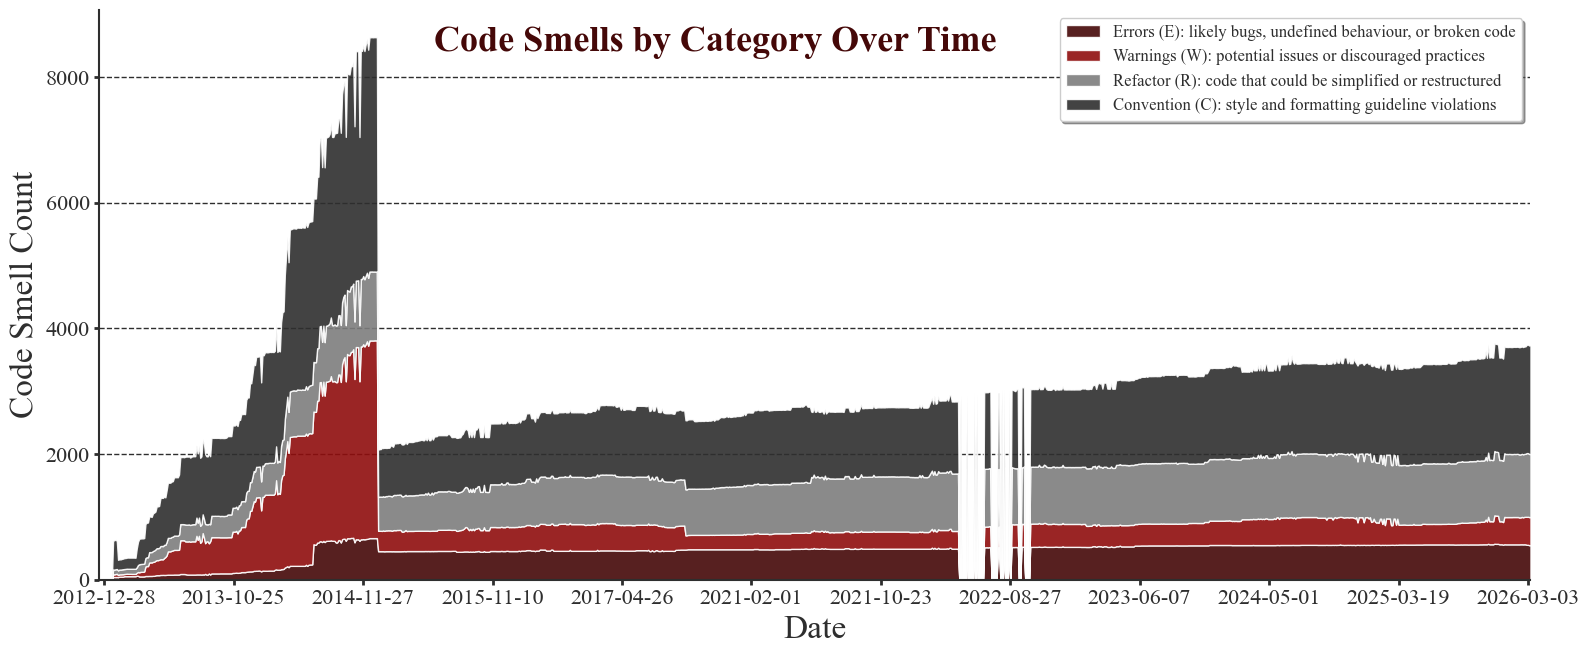

In [82]:
stream_data = build_stream_data(df)
fig = plot_streamgraph(stream_data, df, save=True)

In [83]:
simian_path = BASE_DIR / "../data/wger-results/simian_analysis/duplication_history.csv"
df_simian = pd.read_csv(simian_path)

In [114]:
def plot_simian_duplication(df: pd.DataFrame, save: bool = True) -> plt.Figure:
    """
    Plot the duplication percentage over time for the simian data.
    Optionally saves the figure to output_dir.
    """
    # Prepare data: convert timestamps to date strings
    timestamps = (
        pd.to_datetime(df["Timestamp"], utc=True)
        .dt.date
        .astype(str)
        .tolist()
    )
    duplication_percent = df["DuplicationPercent"].tolist()
    positions = list(range(len(timestamps)))

    # Create figure
    fig, ax = plt.subplots(figsize=(14, 8), facecolor="white")

    # Title
    fig.text(
        0.5, 0.93,
        "Code Duplication Percentage Over Time",
        fontsize=24, color=colors["DarkPastelRed"],
        ha="center", fontweight="bold",
    )

    # Plot
    ax.plot(
        positions,
        duplication_percent,
        color=colors["DarkPastelRed"],
        linewidth=2.5,
        alpha=0.85,
        markersize=6,
        markerfacecolor="white",
        markeredgewidth=1.5,
        markeredgecolor=colors["DarkPastelRed"],
    )

    # Style
    style_axes(ax)

    # Labels
    ax.set_xlabel("Date", fontsize=24, color=colors["SlateGrey"])
    ax.set_ylabel("Duplication %", fontsize=24, color=colors["SlateGrey"])

    # Ticks
    tick_pos = make_xtick_positions(timestamps)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(
        [timestamps[i] for i in tick_pos], ha="center",
        fontsize=13, color=colors["SlateGrey"],
    )
    
    
    ax.tick_params(axis="x", colors=colors["SlateGrey"], labelsize=13, width=2)
    ax.tick_params(axis="y", colors=colors["SlateGrey"], labelsize=16, width=2)

    # Layout
    plt.tight_layout(rect=[0.1, 0, 1, 0.95])

    ax.set_xlim(00, 860)
    # Save
    if save:
        OUTPUT_DIR.mkdir(exist_ok=True)
        out_path = OUTPUT_DIR / "simian_duplication_over_time.png"
        fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved → {out_path}")

    return fig


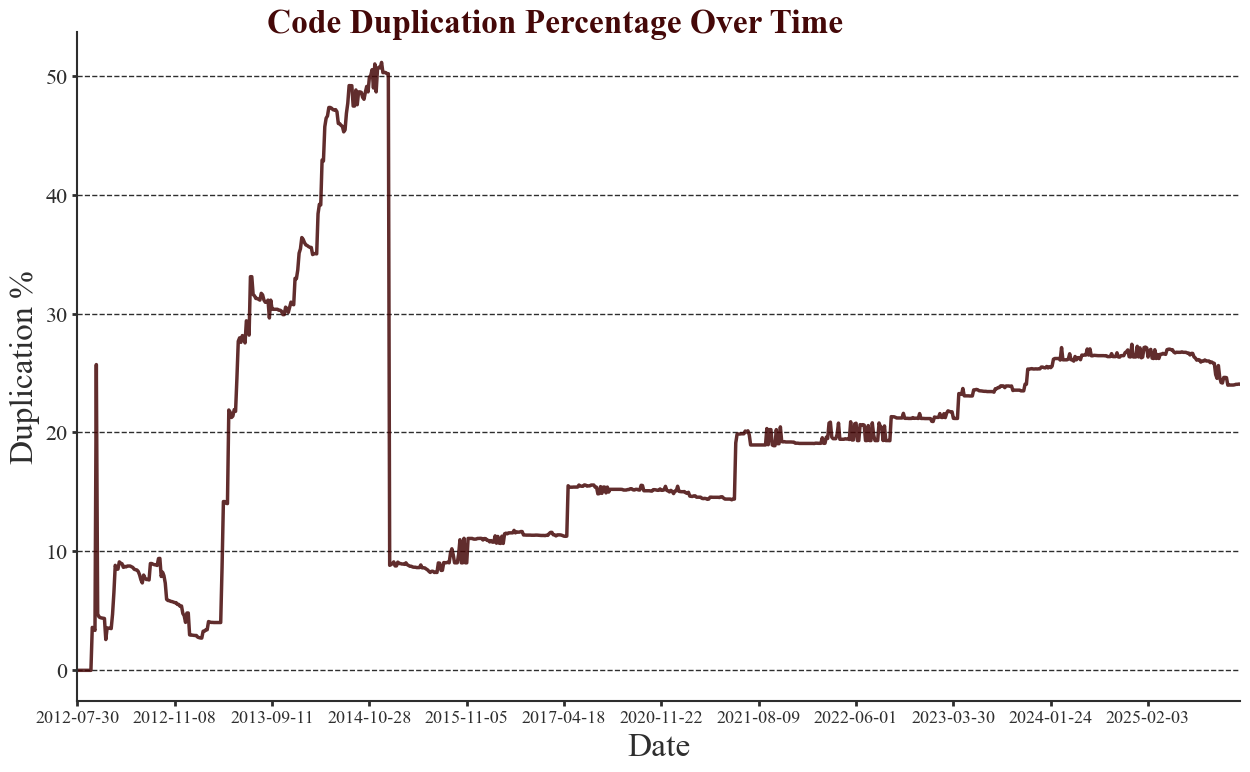

In [115]:
fig = plot_simian_duplication(df_simian, save=False)